### Contexto e Objetivo

Está sendo desenvolvido um modelo de classificação de dados em uma base de serviço para avaliar se um cliente irá continuar no serviço ou irá cancelá-lo. Essa analise poderá ser util para identificar as chances do cliente querer desistir do serviço que possui, e avaliar os fatores que podem afetar nessa decisão


Importação de Dependências

In [1]:
from functions import gini_coeficient

import pandas as pd
import numpy as np 

import seaborn as sns
import matplotlib.pyplot as plt 

import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.precision', 2)

In [2]:
df_credit = pd.read_csv(r"..\\documents\\Credit_Card_Churn.csv")

# Análise Inicial da base de Crédito

In [3]:
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10000 non-null  int64  
 1   Attrition_Flag            10000 non-null  object 
 2   Customer_Age              10000 non-null  int64  
 3   Gender                    10000 non-null  object 
 4   Dependent_count           10000 non-null  int64  
 5   Education_Level           10000 non-null  object 
 6   Marital_Status            10000 non-null  object 
 7   Income_Category           10000 non-null  object 
 8   Card_Category             10000 non-null  object 
 9   Months_on_book            10000 non-null  int64  
 10  Total_Relationship_Count  10000 non-null  int64  
 11  Months_Inactive_12_mon    10000 non-null  int64  
 12  Contacts_Count_12_mon     10000 non-null  int64  
 13  Credit_Limit              10000 non-null  float64
 14  Total_R

Análise de valores únicos

In [4]:
for x in df_credit.columns:
    print(f'Coluna: {x}')
    print(np.sort(df_credit[x].unique()), "\n")
    

Coluna: CLIENTNUM
[100000000 100000001 100000002 ... 100009997 100009998 100009999] 

Coluna: Attrition_Flag
['Attrited Customer' 'Existing Customer'] 

Coluna: Customer_Age
[26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49
 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72] 

Coluna: Gender
['F' 'M'] 

Coluna: Dependent_count
[0 1 2 3 4 5] 

Coluna: Education_Level
['College' 'Doctorate' 'Graduate' 'High School' 'Post-Graduate'
 'Uneducated'] 

Coluna: Marital_Status
['Divorced' 'Married' 'Single'] 

Coluna: Income_Category
['$120K +' '$40K - $60K' '$60K - $80K' '$80K - $120K' 'Less than $40K'
 'Unknown'] 

Coluna: Card_Category
['Blue' 'Gold' 'Platinum' 'Silver'] 

Coluna: Months_on_book
[12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35
 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59
 60] 

Coluna: Total_Relationship_Count
[1 2 3 4 5 6] 

Coluna: Months_Inactive_12_mon
[0 1 2 3 4 5 6] 

Coluna: 

Avaliar se nos valores numericos apresentam valores abaixo de 0

In [5]:
colunas_numericas = [c for c in df_credit.columns if df_credit[c].dtype != 'object']

print("Colunas com valores abaixo de 0:\n")

for c in colunas_numericas:
    if (df_credit[c] < 0).any():
        print(c)


Colunas com valores abaixo de 0:

Avg_Open_To_Buy


In [6]:
# substituição dos valores negativos por 0

df_credit['Avg_Open_To_Buy'] = df_credit['Avg_Open_To_Buy'].map(lambda x: 0 if x < 0 else x)


In [7]:
# Análise percentual de clientes que cancelaram o cartão de crédito

df_credit['Attrition_Flag'].value_counts(normalize=True)

Attrition_Flag
Existing Customer    0.85
Attrited Customer    0.15
Name: proportion, dtype: float64

In [8]:
# Análise percentual de clientes que cancelaram o cartão de crédito por tipo de cartão

df_credit.groupby("Card_Category")['Attrition_Flag'].value_counts(normalize=True)

Card_Category  Attrition_Flag   
Blue           Existing Customer    0.84
               Attrited Customer    0.16
Gold           Existing Customer    0.87
               Attrited Customer    0.13
Platinum       Existing Customer    0.90
               Attrited Customer    0.10
Silver         Existing Customer    0.86
               Attrited Customer    0.14
Name: proportion, dtype: float64

Adaptação dos Dados

In [ ]:
# Nessa etapa será adaptada as colunas string que serão testadas nos modelos

df_base_credit = df_credit.copy()

income_category_map = {"Less than $40K": 1, "$40K - $60K": 2,
                       "$60K - $80K": 3, "$80K - $120K": 4, "$120K +": 5} # "Unknown": 0,

atrition_flag_map = {
    'Existing Customer': 1,
    'Attrited Customer': 0
}

df_base_credit['Is_Male'] = df_base_credit['Gender'].map(lambda x: x == 'M').astype("int")
df_base_credit['Is_Female'] = df_base_credit['Gender'].map(lambda x: x == 'F').astype("int")

df_base_credit['Attrition_Flag'] = df_base_credit['Attrition_Flag'].map(atrition_flag_map).astype("int")


df_base_credit['Income_Category'] = df_base_credit['Income_Category'].map(income_category_map)


# foi calculado a mediana pois com o valor Unknown daria a entender que seria o menor renda possivel
mediana_income_category = df_base_credit['Income_Category'].median()

df_base_credit['Income_Category'] = df_base_credit['Income_Category'].fillna(mediana_income_category).astype("int")


df_base_credit['Is_Uneducated'] = df_base_credit['Education_Level'].map(lambda x: x == 'Uneducated').astype("int")

df_base_credit['Education_HighSchool'] = df_base_credit['Education_Level'].map(
                                                                            lambda x: x == 'High School'
                                                                        ).astype("int")

df_base_credit['Education_College'] = df_base_credit['Education_Level'].map(
                                                                            lambda x: x == 'College'
                                                                        ).astype("int")

df_base_credit['Education_Graduate'] = df_base_credit['Education_Level'].map(
                                                                            lambda x: x == 'Graduate'
                                                                        ).astype("int")

df_base_credit['Education_Post_Graduate'] = df_base_credit['Education_Level'].map(
                                                                            lambda x: x == 'Post-Graduate'
                                                                        ).astype("int")

df_base_credit['Education_Doctorate'] = df_base_credit['Education_Level'].map(
                                                                            lambda x: x == 'Doctorate'
                                                                        ).astype("int")



df_base_credit['Status_Divorced'] = df_base_credit['Marital_Status'].map(lambda x: x == 'Divorced').astype("int")
df_base_credit['Status_Single'] = df_base_credit['Marital_Status'].map(lambda x: x == 'Single').astype("int")
df_base_credit['Status_Married'] = df_base_credit['Marital_Status'].map(lambda x: x == 'Married').astype("int")

df_base_credit['Is_Blue_Card'] = df_base_credit['Card_Category'].map(lambda x: x == 'Blue').astype("int")
df_base_credit['Is_Silver_Card'] = df_base_credit['Card_Category'].map(lambda x: x == 'Silver').astype("int")
df_base_credit['Is_Gold_Card'] = df_base_credit['Card_Category'].map(lambda x: x == 'Gold').astype("int")
df_base_credit['Is_Platinum_Card'] = df_base_credit['Card_Category'].map(lambda x: x == 'Platinum').astype("int")


Validação das colunas com alta correlação com o target

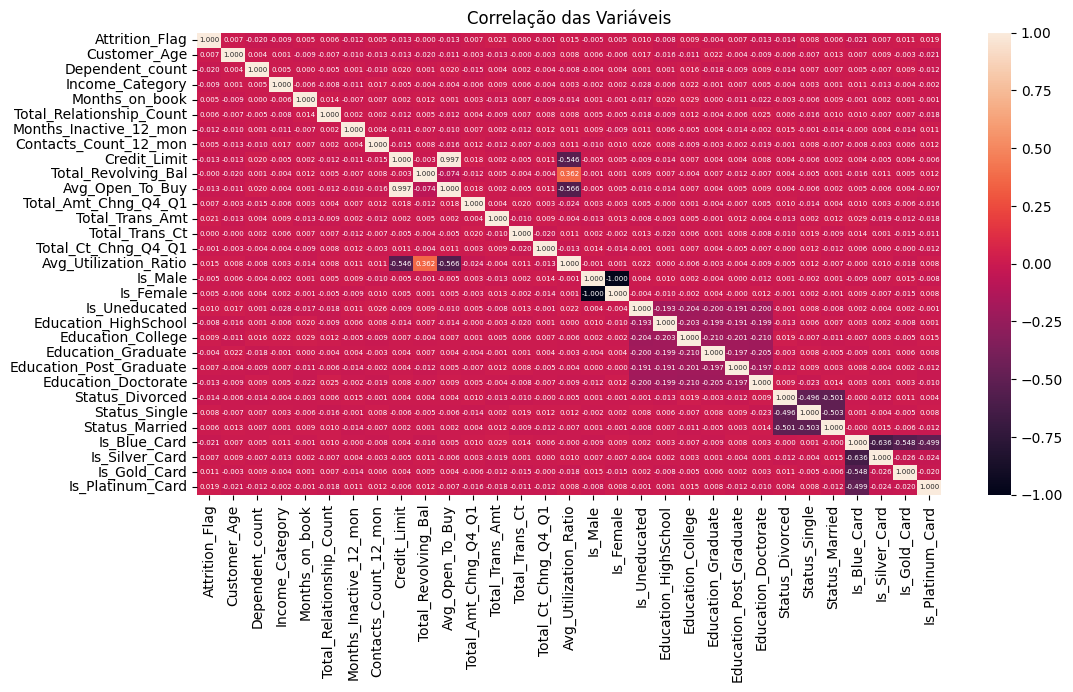

In [11]:
base_correlacao = df_base_credit.drop(columns=['Gender', 'CLIENTNUM', 
                                               'Marital_Status', 'Card_Category', 
                                               'Education_Level']).corr()

plt.figure(figsize=(12, 6))

sns.heatmap(data=base_correlacao, 
            annot=True, fmt=".3f", annot_kws={"size": 5})
plt.title("Correlação das Variáveis")
plt.show()

Conlusões

* A coluna Is_Female representa uma redundância da coluna Is_Male, portanto
  não sendo necessaria para analise do modelo de classificação

* A coluna Avg_Open_To_By é o calculo do credito limite menos
  o valor que fo utilizado, é matematicamente identico ao Credit_Limit

* A coluna CLIENTNUM será removida pois apresenta valores repetidos, 
  e então atrapalhando na classificação dos dados


In [12]:
df_base_credit = df_base_credit.drop(columns=['CLIENTNUM', 'Gender', 'Marital_Status', 
                                              'Card_Category', 'Is_Female', 
                                              'Avg_Open_To_Buy', 'Education_Level'])


Definição das variáveis de treino e teste

In [13]:
X = df_base_credit.drop(columns=['Attrition_Flag'], axis=1)
y = df_base_credit['Attrition_Flag']

# Será dividido os dados dos eixos x e y em 80% de treino e 20% de teste
# stratify -> variável alvo
# random_state -> trava o sorteio para ser sempre igual

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42, stratify=y)

# Modelo de Regressão Logística

In [14]:
# Deve ser aplicado o StandardScaler para que o Modelo de Regressão Logística
# consiga colocar todas as variáveis na mesma escala

scaler = StandardScaler()

X_train_scalled = scaler.fit_transform(X_train)
X_test_scalled = scaler.transform(X_test)

In [ ]:
# Modelo Logistic Regression
logistic_regression = LogisticRegression(class_weight='balanced', max_iter=2000)
logistic_regression.fit(X_train_scalled, Y_train)


array([0.50014191, 0.46881719, 0.48518643, ..., 0.51244537, 0.4888126 ,
       0.52669101], shape=(2000,))

In [47]:
# Obtenção de Probabilidades (importante para o Gini), 
# Será pego a probabilidade de Churn (classe 1)
prob_lr = logistic_regression.predict_proba(X_test_scalled)[:, 1]


# Coeficiente de Gini
# caso o coeficiente esteja menor que 0 quer dizer que o modelo está invertendo previsões
# se for 0 o modelo é aleatiro, se for 1 o modelo é perfeito

gini_lr = gini_coeficient(Y_test, prob_lr)

print(f'Coeficiente de Gini (Logistic Regression): {gini_lr}')

Coeficiente de Gini (Logistic Regression): 0.0701928095545119


In [52]:
# Previsão do modelo
pred_lr = logistic_regression.predict(X_test_scalled)

print(f"Matriz de Confusão:\n{confusion_matrix(Y_test, pred_lr)}\n")

print(f"Relatório Logistic Regression:\n {
                classification_report(Y_test, pred_lr, target_names=['Churn', 'Permaneceu'])
            }")



Matriz de Confusão:
[[166 142]
 [834 858]]

Relatório Logistic Regression:
               precision    recall  f1-score   support

       Churn       0.17      0.54      0.25       308
  Permaneceu       0.86      0.51      0.64      1692

    accuracy                           0.51      2000
   macro avg       0.51      0.52      0.45      2000
weighted avg       0.75      0.51      0.58      2000



In [45]:
# Análise de quais colunas estão afetando o Modelo

pd.DataFrame({
    'Coluna': X_train.columns,
    'Coeficiente': logistic_regression.coef_[0]   
}).sort_values(by='Coeficiente', ascending=False)


,Coluna,Coeficiente
13,Avg_Utilization_Ratio,5.08e-02
10,Total_Trans_Amt,3.88e-02
26,Is_Gold_Card,3.51e-02
19,Education_Post_Graduate,2.83e-02
17,Education_College,2.70e-02
22,Status_Single,2.70e-02
27,Is_Platinum_Card,2.30e-02
4,Total_Relationship_Count,1.76e-02
9,Total_Amt_Chng_Q4_Q1,1.55e-02
15,Is_Uneducated,9.74e-03


# Random Florest

In [ ]:
# Modelo Random Florest

# criação do modelo
random_florest = RandomForestClassifier(class_weight='balanced', random_state=42) 
# class_weight: Balanceamento de pesos

# treinar o modelo
random_florest.fit(X_train, Y_train)


In [58]:
# Obtenção de Probabilidades (importante para o Gini), 
# Será pego a probabilidade de Churn (classe 1)
prob_rf = random_florest.predict_proba(X_test)[:, 1]


# Coeficiente de Gini
# caso o coeficiente esteja menor que 0 quer dizer que o modelo está invertendo previsões
# se for 0 o modelo é aleatiro, se for 1 o modelo é perfeito

gini_rf = gini_coeficient(Y_test, prob_rf)

print(f'Coeficiente de Gini (Random Florest): {gini_rf}')

Coeficiente de Gini (Random Florest): 0.002337201805286737


In [ ]:
# Previsão do modelo
pred_rf = random_florest.predict(X_test)

print(f"Matriz de Confusão:\n{confusion_matrix(Y_test, pred_rf)}\n")

print(f"Relatório Random Florest:\n {
                classification_report(
                    Y_test, pred_rf, target_names=['Churn', 'Permaneceu']
                )
            }")


Matriz de Confusão:
[[   0  308]
 [   0 1692]]

Relatório Random Florest:
               precision    recall  f1-score   support

       Churn       0.00      0.00      0.00       308
  Permaneceu       0.85      1.00      0.92      1692

    accuracy                           0.85      2000
   macro avg       0.42      0.50      0.46      2000
weighted avg       0.72      0.85      0.78      2000



c:\Users\rpf97\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rpf97\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rpf97\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [60]:
df_importancia = pd.DataFrame({
    'Coluna': X_train.columns,
    'Importância': random_florest.feature_importances_  
}).sort_values(by='Importância', ascending=False)

df_importancia

,Coluna,Importância
10,Total_Trans_Amt,8.73e-02
8,Total_Revolving_Bal,8.61e-02
9,Total_Amt_Chng_Q4_Q1,8.48e-02
12,Total_Ct_Chng_Q4_Q1,8.39e-02
7,Credit_Limit,8.29e-02
11,Total_Trans_Ct,7.94e-02
0,Customer_Age,7.17e-02
3,Months_on_book,7.16e-02
13,Avg_Utilization_Ratio,5.87e-02
6,Contacts_Count_12_mon,3.92e-02


# XGBOOT Classifier

In [69]:
# criação do modelo
xgboot_classifier = xgb.XGBClassifier(scale_pos_weight=5.5  # incluir mais 5.5 de peso ao churn
                                      , random_state=42) 

# treinar o modelo
xgboot_classifier.fit(X_train, Y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [70]:
# Obtenção de Probabilidades (importante para o Gini), 
# Será pego a probabilidade de Churn (classe 1)
prob_xgboot = xgboot_classifier.predict_proba(X_test)[:, 1]


# Coeficiente de Gini
# caso o coeficiente esteja menor que 0 quer dizer que o modelo está invertendo previsões
# se for 0 o modelo é aleatiro, se for 1 o modelo é perfeito

gini_xgboot = gini_coeficient(Y_test, prob_xgboot)

print(f'Coeficiente de Gini (XGBOOST Classifier): {gini_xgboot}')

Coeficiente de Gini (XGBOOST Classifier): -0.005748979153234468


In [ ]:
# Previsão do modelo
pred_xgboot = xgboot_classifier.predict(X_test_scalled)

print(f"Matriz de Confusão:\n{confusion_matrix(Y_test, pred_xgboot)}\n")

print(f"Relatório XGBOOST Classifier:\n {
                classification_report(
                    Y_test, pred_xgboot, target_names=['Churn', 'Permaneceu']
                )
            }")


Matriz de Confusão:
[[ 259   49]
 [1398  294]]

Relatório Random Florest:
               precision    recall  f1-score   support

       Churn       0.16      0.84      0.26       308
  Permaneceu       0.86      0.17      0.29      1692

    accuracy                           0.28      2000
   macro avg       0.51      0.51      0.28      2000
weighted avg       0.75      0.28      0.29      2000



In [72]:
df_importancia = pd.DataFrame({
    'Coluna': X_train.columns,
    'Importância': xgboot_classifier.feature_importances_  
}).sort_values(by='Importância', ascending=False)

df_importancia

,Coluna,Importância
25,Is_Silver_Card,0.05
26,Is_Gold_Card,0.05
23,Status_Married,0.04
2,Income_Category,0.04
14,Is_Male,0.04
15,Is_Uneducated,0.04
4,Total_Relationship_Count,0.04
11,Total_Trans_Ct,0.04
9,Total_Amt_Chng_Q4_Q1,0.04
12,Total_Ct_Chng_Q4_Q1,0.04
